# Chapter 3: Statistical Experiments and Significance Testing
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(lmPerm)
library(pwr)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Resampling
#### Example: Web Stickiness

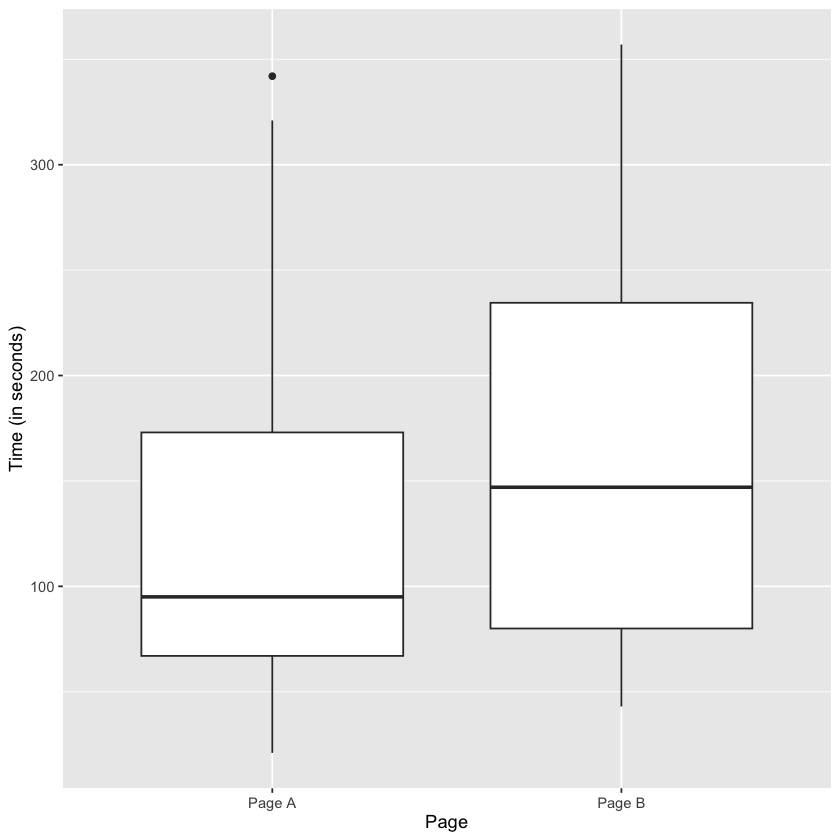

In [1]:
session_times <- read_csv(file.path(DATA_DIR, "web_page_data.csv"), show_col_types = FALSE) %>%
  mutate(Time = Time * 100)

ggplot(session_times, aes(x = Page, y = Time)) +
  geom_boxplot() +
  labs(y = "Time (in seconds)")

In [1]:
mean_a <- session_times %>% filter(Page == "Page A") %>% pull("Time") %>% mean()
mean_b <- session_times %>% filter(Page == "Page B") %>% pull("Time") %>% mean()
mean_b - mean_a

[1] 35.66667

In [1]:
perm_fun <- function(x, n_a) {
  n <- length(x)
  x_resampled <- sample(x)
  x_a <- x_resampled[1:n_a]
  x_b <- x_resampled[(n_a + 1):n]
  return(mean(x_b) - mean(x_a))
}

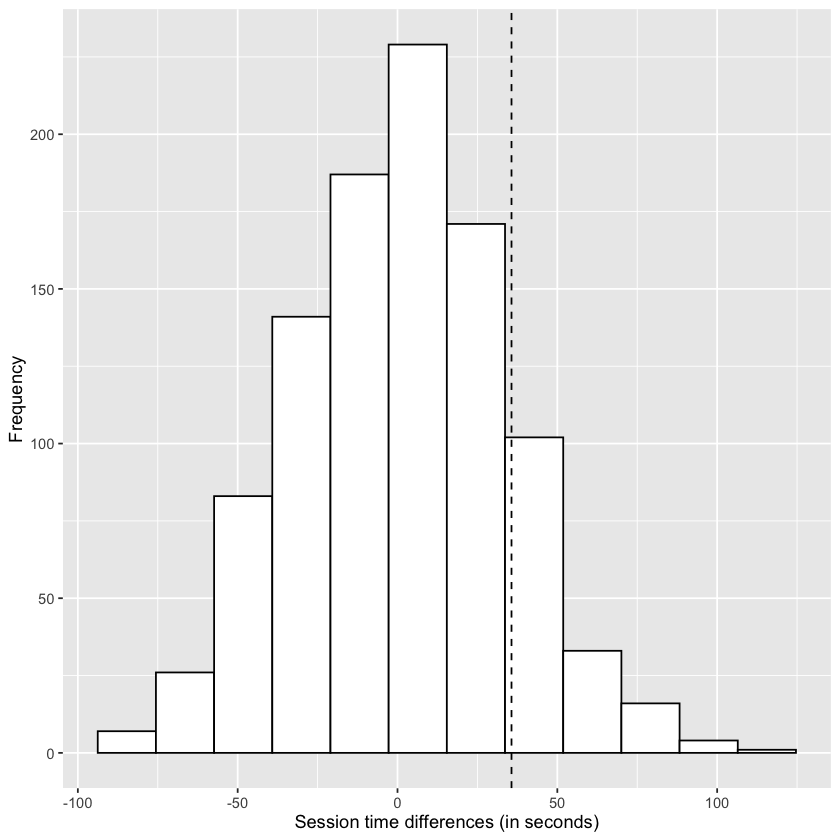

In [1]:
set.seed(1)
perm_diffs <- rep(0, 1000)
for (i in 1:1000) {
  perm_diffs[i] <- perm_fun(session_times %>% pull(Time), 21)
}
ggplot(tibble(perm_diffs = perm_diffs), aes(x = perm_diffs)) +
  geom_histogram(bins = 12, color = "black", fill = "white") +
  geom_vline(xintercept = mean_b - mean_a, linetype = "dashed") +
  labs(x = "Session time differences (in seconds)", y = "Frequency")

In [1]:
mean(perm_diffs > (mean_b - mean_a))

[1] 0.144

### Statistical Significance and p-Values

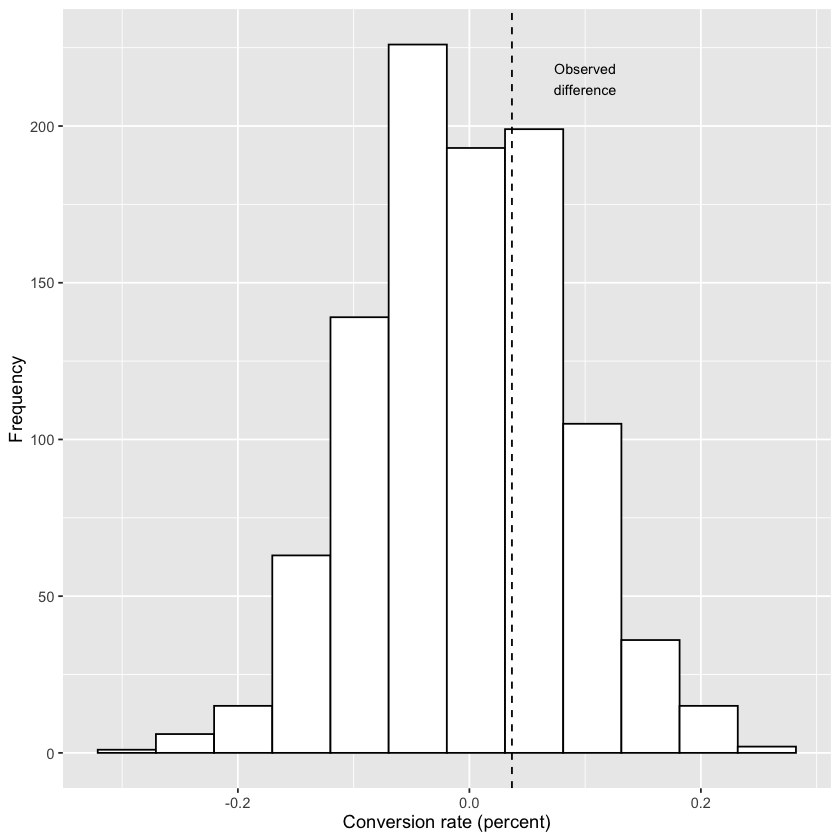

In [1]:
obs_pct_diff <- 100 * (200 / 23739 - 182 / 22588)
conversion <- c(rep(0, 45945), rep(1, 382))
perm_diffs <- rep(0, 1000)
for (i in 1:1000) {
  perm_diffs[i] <- 100 * perm_fun(conversion, 23739)
}
ggplot(tibble(perm_diffs = perm_diffs), aes(x = perm_diffs)) +
  geom_histogram(bins = 12, color = "black", fill = "white") +
  geom_vline(xintercept = obs_pct_diff, linetype = "dashed") +
  labs(x = "Conversion rate (percent)", y = "Frequency") +
  annotate("text", x = 0.1, y = 215, label = "Observed\ndifference", size = 3)

#### p-Value

In [1]:
mean(perm_diffs > obs_pct_diff)

[1] 0.313

In [1]:
prop.test(x = c(200, 182), n = c(23739, 22588), alternative = "greater")


	2-sample test for equality of proportions with continuity correction

data:  c(200, 182) out of c(23739, 22588)
X-squared = 0.14893, df = 1, p-value = 0.3498
alternative hypothesis: greater
95 percent confidence interval:
 -0.001057439  1.000000000
sample estimates:
     prop 1      prop 2 
0.008424955 0.008057376 


### t-Tests

In [1]:
t.test(Time ~ Page, data = session_times, alternative = "less")


	Welch Two Sample t-test

data:  Time by Page
t = -1.0983, df = 27.693, p-value = 0.1408
alternative hypothesis: true difference in means between group Page A and group Page B is less than 0
95 percent confidence interval:
     -Inf 19.59674
sample estimates:
mean in group Page A mean in group Page B 
            126.3333             162.0000 


### ANOVA

In [1]:
four_sessions  <- read_csv(file.path(DATA_DIR, "four_sessions.csv"), show_col_types = FALSE)
summary(aovp(Time ~ Page, data = four_sessions))

[1] "Settings:  unique SS "


Component 1 :
            Df R Sum Sq R Mean Sq Iter Pr(Prob)    
Page1        3    831.4    277.13 5000    4e-04 ***
Residuals   16   1618.4    101.15                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


#### F-Statistic

In [1]:
summary(aov(Time ~ Page, data = four_sessions))

            Df Sum Sq Mean Sq F value Pr(>F)  
Page         3  831.4   277.1    2.74 0.0776 .
Residuals   16 1618.4   101.2                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Chi-Square Test
#### Chi-Square Test: A Resampling Approach

In [1]:
click_rate <-  read_csv(file.path(DATA_DIR, "click_rates.csv"), show_col_types = FALSE)
clicks <- click_rate %>%
  pivot_wider(id_cols = Headline, names_from = Click, values_from = Rate) %>%
  select(Click, `No-click`)
chisq.test(clicks, simulate.p.value = TRUE)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  clicks
X-squared = 1.6659, df = NA, p-value = 0.4893


#### Chi-Square Test: Statistical Theory

In [1]:
chisq.test(clicks, simulate.p.value = FALSE)


	Pearson's Chi-squared test

data:  clicks
X-squared = 1.6659, df = 2, p-value = 0.4348


#### Fisher's Exact Test

In [1]:
fisher.test(clicks)


	Fisher's Exact Test for Count Data

data:  clicks
p-value = 0.4824
alternative hypothesis: two.sided


### Power and Sample Size
#### Sample Size

In [1]:
effect_size <- ES.h(p1 = 0.0121, p2 = 0.011)
pwr.2p.test(h = effect_size, sig.level = 0.05, power = 0.8,
  alternative = "greater")


     Difference of proportion power calculation for binomial distribution (arcsine transformation) 

              h = 0.01029785
              n = 116601.7
      sig.level = 0.05
          power = 0.8
    alternative = greater

NOTE: same sample sizes


In [1]:
effect_size <- ES.h(p1 = 0.0165, p2 = 0.011)
pwr.2p.test(h = effect_size, sig.level = 0.05, power = 0.8,
  alternative = "greater")


     Difference of proportion power calculation for binomial distribution (arcsine transformation) 

              h = 0.04746819
              n = 5487.731
      sig.level = 0.05
          power = 0.8
    alternative = greater

NOTE: same sample sizes


# Supplementary Material
## Alternative to t-test using statsmodels

## Figure 3-6. Boxplots of the four groups show considerable differences among them

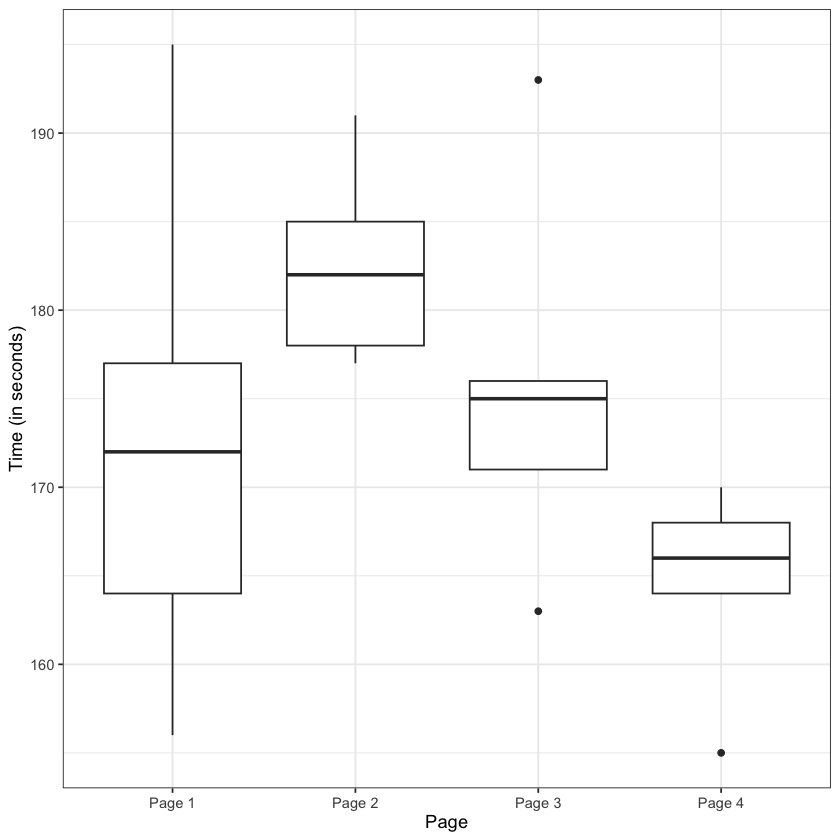

In [1]:
graph <- ggplot(four_sessions, aes(x = Page, y = Time)) +
  geom_boxplot() +
  labs(y = "Time (in seconds)") +
  theme_bw()
graph

## Visualizing the resampling results for ANOVA

## chi-2 test using sampling with replacement

## Figure 3-7. Chi-square distribution with various degrees of freedom

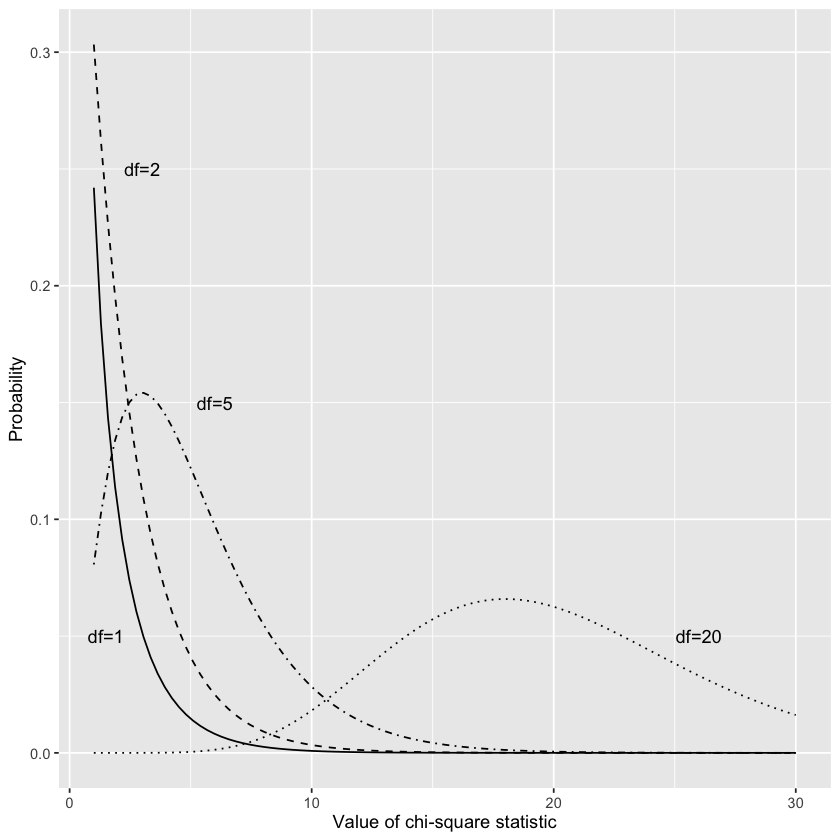

In [1]:
chi <- tibble(x = 1 + (0:99) * (30 - 1) / 99) %>%
  mutate(
    chi_1 = dchisq(x, df = 1),
    chi_2 = dchisq(x, df = 2),
    chi_5 = dchisq(x, df = 5),
    chi_10 = dchisq(x, df = 10),
    chi_20 = dchisq(x, df = 20),
  )
ggplot(chi, aes(x = x)) +
  geom_line(aes(y = chi_1), linetype = 1) +
  geom_line(aes(y = chi_2), linetype = 2) +
  geom_line(aes(y = chi_5), linetype = 4) +
  geom_line(aes(y = chi_20), linetype = 3) +
  labs(x = "Value of chi-square statistic", y = "Probability") +
  annotate("text", 1.5, 0.05, label = "df=1") +
  annotate("text", 3, 0.25, label = "df=2") +
  annotate("text", 6, 0.15, label = "df=5") +
  # annotate("text", 10, 0.1, label = "df=10") +
  annotate("text", 26, 0.05, label = "df=20")

## Figure 3-8. Frequency histogram for Imanishi-Kari lab data

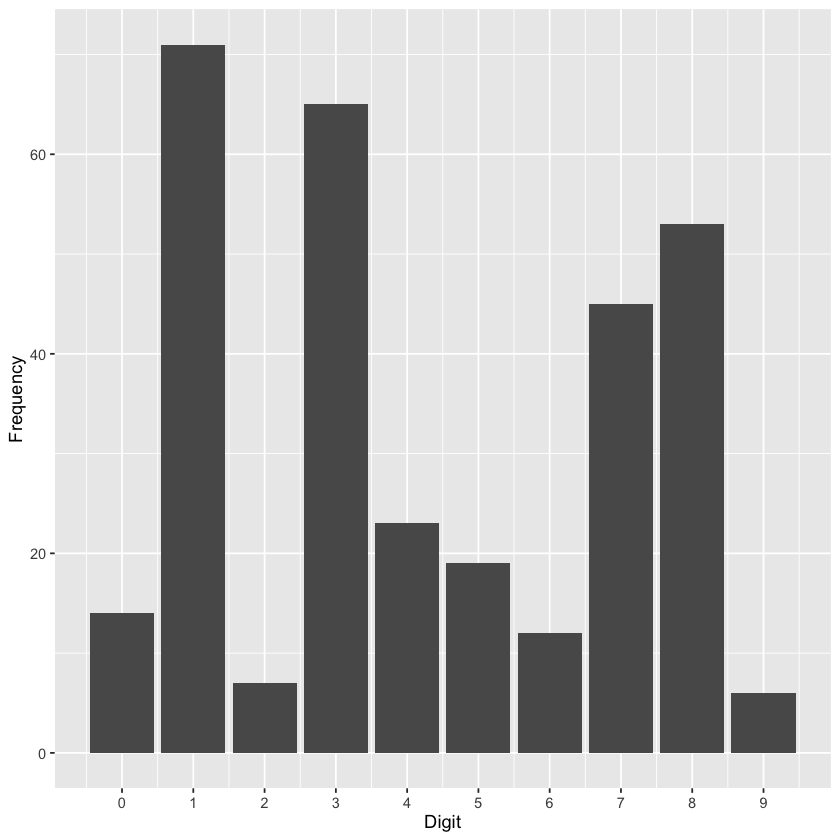

In [1]:
imanishi <- read_csv(file.path(DATA_DIR, "imanishi_data.csv"), show_col_types = FALSE)
ggplot(imanishi, aes(x = Digit, y = Frequency)) +
  geom_col() +
  scale_x_continuous(breaks = 0:9, labels = 0:9)